# Hotel booking cancellation analysis

A reproducible, notebook-first binary-classification study of the Kaggle **Hotel booking demand** dataset. The positive class is `is_canceled = 1`.

## 1. Business problem

Hotels must plan rooms, staffing, and inventory before arrival, but some reservations are canceled. This analysis asks:

1. Which booking segments have higher observed cancellation rates?
2. How much booked room-night volume and ADR-based booking value are associated with canceled reservations?
3. Can a leakage-safe model estimate cancellation risk when the reservation is made?

The model returns a class prediction and a cancellation probability. Both are risk estimates learned from historical associations. They are not certainties, causal explanations, or proof that a policy change will reduce cancellations.

### Evaluation protocol

A stratified 20% test set is reserved before exploratory analysis. All cleaning rules that learn statistics, exploratory analysis, model comparison, and selection use training rows only. The untouched test set is evaluated once after the preferred model is selected from cross-validation. Because bookings span multiple years, a chronological split would be preferable for future production validation.

## 2. Environment and reproducibility

All randomized operations use `random_state=42` or CatBoost's `random_seed=42`. Numeric imputers, categorical imputers, scaling, and one-hot encoding live inside scikit-learn pipelines, so every cross-validation fold learns preprocessing only from its own training rows.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import warnings

import catboost
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

RANDOM_STATE = 42
TEST_SIZE = 0.20
F1_TIE_TOLERANCE = 0.005
TARGET = "is_canceled"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__} | pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__} | CatBoost: {catboost.__version__}")

Python: 3.12.14
NumPy: 2.2.6 | pandas: 2.2.3
scikit-learn: 1.7.2 | CatBoost: 1.2.8


## 3. Data loading and validation

Run the notebook from the repository root. The original CSV is read once from `data/hotel_bookings.csv`; `raw_data` is never modified. Validation reports the observed schema and data quality rather than assuming a row count, data type, missingness pattern, or class balance.

In [2]:
DATA_PATH = Path("data") / "hotel_bookings.csv"

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Follow the Kaggle download steps in README.md."
    )

raw_data = pd.read_csv(DATA_PATH)
if TARGET not in raw_data.columns:
    raise ValueError(f"Required target column {TARGET!r} is missing.")
if not set(raw_data[TARGET].dropna().unique()).issubset({0, 1}):
    raise ValueError("The target must contain only 0 (not canceled) and 1 (canceled).")

file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print(f"Relative path: {DATA_PATH.as_posix()}")
print(f"File size: {DATA_PATH.stat().st_size:,} bytes")
print(f"SHA-256: {file_hash}")
print(f"Observed shape: {raw_data.shape[0]:,} rows x {raw_data.shape[1]} columns")
display(raw_data.head())

Relative path: data/hotel_bookings.csv
File size: 16,855,599 bytes
SHA-256: 7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06
Observed shape: 119,390 rows x 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.000,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.000,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.000,NaN,0,Transient,75.000,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.000,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.000,NaN,0,Transient,98.000,0,1,Check-Out,2015-07-03


In [3]:
column_profile = pd.DataFrame(
    {
        "dtype": raw_data.dtypes.astype(str),
        "unique_values": raw_data.nunique(dropna=False),
        "missing_values": raw_data.isna().sum(),
        "missing_percent": 100 * raw_data.isna().mean(),
    }
)

print("Column names:")
display(pd.DataFrame({"column": raw_data.columns}))
print("Data types, unique values, and missingness:")
display(column_profile)
print("Descriptive statistics:")
display(raw_data.describe(include="all").T)

Column names:


,column
0,hotel
1,is_canceled
2,lead_time
3,arrival_date_year
4,arrival_date_month
5,arrival_date_week_number
6,arrival_date_day_of_month
7,stays_in_weekend_nights
8,stays_in_week_nights
9,adults


Data types, unique values, and missingness:


,dtype,unique_values,missing_values,missing_percent
hotel,object,2,0,0.000
is_canceled,int64,2,0,0.000
lead_time,int64,479,0,0.000
arrival_date_year,int64,3,0,0.000
arrival_date_month,object,12,0,0.000
arrival_date_week_number,int64,53,0,0.000
arrival_date_day_of_month,int64,31,0,0.000
stays_in_weekend_nights,int64,17,0,0.000
stays_in_week_nights,int64,35,0,0.000
adults,int64,14,0,0.000


Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,"119,390.000",NaN,NaN,NaN,0.370,0.483,0.000,0.000,0.000,1.000,1.000
lead_time,"119,390.000",NaN,NaN,NaN,104.011,106.863,0.000,18.000,69.000,160.000,737.000
arrival_date_year,"119,390.000",NaN,NaN,NaN,"2,016.157",0.707,"2,015.000","2,016.000","2,016.000","2,017.000","2,017.000"
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,"119,390.000",NaN,NaN,NaN,27.165,13.605,1.000,16.000,28.000,38.000,53.000
arrival_date_day_of_month,"119,390.000",NaN,NaN,NaN,15.798,8.781,1.000,8.000,16.000,23.000,31.000
stays_in_weekend_nights,"119,390.000",NaN,NaN,NaN,0.928,0.999,0.000,0.000,1.000,2.000,19.000
stays_in_week_nights,"119,390.000",NaN,NaN,NaN,2.500,1.908,0.000,1.000,2.000,3.000,50.000
adults,"119,390.000",NaN,NaN,NaN,1.856,0.579,0.000,2.000,2.000,2.000,55.000


In [4]:
exact_duplicate_rows = int(raw_data.duplicated().sum())
target_distribution = (
    raw_data[TARGET]
    .value_counts(dropna=False)
    .sort_index()
    .rename(index={0: "Not canceled (0)", 1: "Canceled (1)"})
    .to_frame("bookings")
)
target_distribution["percent"] = 100 * target_distribution["bookings"] / len(raw_data)

categorical_columns_raw = raw_data.select_dtypes(include=["object", "category"]).columns
categorical_cardinality = (
    raw_data[categorical_columns_raw]
    .nunique(dropna=False)
    .sort_values(ascending=False)
    .to_frame("unique_values_including_missing")
)

month_numbers = raw_data["arrival_date_month"].map(
    {
        month: number
        for number, month in enumerate(
            [
                "January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December",
            ],
            start=1,
        )
    }
)
arrival_dates = pd.to_datetime(
    {
        "year": raw_data["arrival_date_year"],
        "month": month_numbers,
        "day": raw_data["arrival_date_day_of_month"],
    },
    errors="coerce",
)
status_dates = pd.to_datetime(raw_data["reservation_status_date"], errors="coerce")

print(f"Exact duplicate rows: {exact_duplicate_rows:,}")
print(
    "They are retained: the file has no reservation identifier, so identical recorded "
    "attributes can represent separate bookings and do not prove duplicate transactions."
)
display(target_distribution)
print("Categorical cardinality:")
display(categorical_cardinality)
print(f"Arrival date range: {arrival_dates.min().date()} to {arrival_dates.max().date()}")
print(f"Reservation-status date range: {status_dates.min().date()} to {status_dates.max().date()}")
print(f"Invalid constructed arrival dates: {arrival_dates.isna().sum():,}")
print(f"Invalid reservation-status dates: {status_dates.isna().sum():,}")

Exact duplicate rows: 31,994
They are retained: the file has no reservation identifier, so identical recorded attributes can represent separate bookings and do not prove duplicate transactions.


,bookings,percent
is_canceled,,
Not canceled (0),75166,62.958
Canceled (1),44224,37.042


Categorical cardinality:


,unique_values_including_missing
reservation_status_date,926
country,178
assigned_room_type,12
arrival_date_month,12
reserved_room_type,10
market_segment,8
distribution_channel,5
meal,5
customer_type,4
deposit_type,3


Arrival date range: 2015-07-01 to 2017-08-31
Reservation-status date range: 2014-10-17 to 2017-09-14
Invalid constructed arrival dates: 0
Invalid reservation-status dates: 0


## 4. Cleaning decisions and data-quality checks

The raw dataframe and CSV remain unchanged. A separate analysis copy applies the following transparent rules:

- `children`: four values are genuinely missing. They remain missing until the numeric imputer learns a median inside each training fold.
- `country`: a missing country is genuinely unknown, so it is labeled `Unknown`.
- `agent` and `company`: missing IDs are structural values meaning no agent or no company. The raw IDs are excluded because they are high-cardinality organizational identifiers; two generalizable binary indicators (`has_agent`, `has_company`) preserve the structural information.
- zero total guests: a booking with no adults, children, or babies is not operationally valid. The three guest-count fields are set to missing in the analysis copy and imputed inside the pipeline; the rows are not dropped.
- negative ADR: a negative average daily rate is invalid for the booking-value proxy. It is set to missing in the analysis copy and imputed inside the modeling pipeline; it is excluded from ADR-value aggregation.
- zero booked nights: these records may be same-day use, administrative records, or data anomalies. They are flagged and retained because the file does not establish that they are erroneous.
- exact duplicate-looking rows are retained for the reason documented above. No rows are silently removed.

In [5]:
data = raw_data.copy()
data["arrival_date"] = arrival_dates
data["country"] = data["country"].fillna("Unknown")
data["has_agent"] = data["agent"].notna().astype("int8")
data["has_company"] = data["company"].notna().astype("int8")

total_guests_raw = data[["adults", "children", "babies"]].fillna(0).sum(axis=1)
zero_guest_mask = total_guests_raw.eq(0)
negative_adr_mask = data["adr"].lt(0)
negative_stay_mask = data[["stays_in_weekend_nights", "stays_in_week_nights"]].lt(0).any(axis=1)
zero_night_mask = data[["stays_in_weekend_nights", "stays_in_week_nights"]].sum(axis=1).eq(0)

data.loc[zero_guest_mask, ["adults", "children", "babies"]] = np.nan
data.loc[negative_adr_mask, "adr"] = np.nan
data["total_nights"] = data["stays_in_weekend_nights"] + data["stays_in_week_nights"]

cleaning_report = pd.DataFrame(
    {
        "issue_or_structural_value": [
            "Missing children (genuine missing)",
            "Missing country (labeled Unknown)",
            "Missing agent (structural: no agent)",
            "Missing company (structural: no company)",
            "Zero total guests (guest counts set to missing)",
            "Negative ADR (set to missing)",
            "Negative stay length",
            "Zero total nights (flagged and retained)",
            "Exact duplicate-looking rows (retained)",
        ],
        "rows": [
            raw_data["children"].isna().sum(),
            raw_data["country"].isna().sum(),
            raw_data["agent"].isna().sum(),
            raw_data["company"].isna().sum(),
            zero_guest_mask.sum(),
            negative_adr_mask.sum(),
            negative_stay_mask.sum(),
            zero_night_mask.sum(),
            exact_duplicate_rows,
        ],
    }
)
display(cleaning_report)
print(f"Rows before cleaning copy: {len(raw_data):,}")
print(f"Rows after documented value handling: {len(data):,}")
assert len(data) == len(raw_data)

,issue_or_structural_value,rows
0,Missing children (genuine missing),4
1,Missing country (labeled Unknown),488
2,Missing agent (structural: no agent),16340
3,Missing company (structural: no company),112593
4,Zero total guests (guest counts set to missing),180
5,Negative ADR (set to missing),1
6,Negative stay length,0
7,Zero total nights (flagged and retained),715
8,Exact duplicate-looking rows (retained),31994


Rows before cleaning copy: 119,390
Rows after documented value handling: 119,390


## 5. Prediction moment and leakage review

The prediction moment is **when the reservation is made**. Features must therefore be available at booking creation.

| Excluded field | Reason |
|---|---|
| `reservation_status`, `reservation_status_date` | Directly reveal the later reservation outcome or its recording date. |
| `assigned_room_type` | Room assignment can occur or change after the reservation is created. |
| `booking_changes` | Counts changes made after the original booking. |
| `days_in_waiting_list` | Reflects downstream processing after booking creation. |
| `required_car_parking_spaces`, `total_of_special_requests` | Their final counts are not timestamped and may be updated after creation; retained for descriptive analysis only. |
| `agent`, `company` | High-cardinality IDs may memorize organizations and fail to generalize; replaced by `has_agent` and `has_company`. |
| derived dates and business-impact fields | Used only for validation or descriptive analysis, not as model inputs. |

`reserved_room_type`, `deposit_type`, quoted `adr`, arrival timing, stay request, booking channel, customer type, country, meal, guest counts, and prior booking history are treated as known when the reservation is created. This is a conservative feature set; a production system should confirm availability and timestamp semantics against source-system documentation.

In [6]:
numeric_features = [
    "lead_time",
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr",
    "has_agent",
    "has_company",
]
categorical_features = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
]
feature_columns = numeric_features + categorical_features

excluded_from_model = sorted(set(data.columns) - set(feature_columns) - {TARGET})
display(
    pd.DataFrame(
        {
            "model_feature": feature_columns,
            "type": [
                "numeric" if feature in numeric_features else "categorical"
                for feature in feature_columns
            ],
        }
    )
)
print("Excluded from modeling:")
print(", ".join(excluded_from_model))

,model_feature,type
0,lead_time,numeric
1,arrival_date_year,numeric
2,arrival_date_week_number,numeric
3,arrival_date_day_of_month,numeric
4,stays_in_weekend_nights,numeric
5,stays_in_week_nights,numeric
6,adults,numeric
7,children,numeric
8,babies,numeric
9,is_repeated_guest,numeric


Excluded from modeling:
agent, arrival_date, assigned_room_type, booking_changes, company, days_in_waiting_list, required_car_parking_spaces, reservation_status, reservation_status_date, total_nights, total_of_special_requests


## 6. Reserve the stratified test set

The row-level 80/20 split follows the requested protocol and preserves target prevalence. With no reservation identifier, a reliable group split is unavailable. Identical feature profiles may therefore appear in both partitions, which is recorded as a limitation. All subsequent exploratory and business-impact analysis uses only `train_frame` until the final evaluation section.

In [7]:
X = data.loc[:, feature_columns].copy()
y = data[TARGET].astype("int8").copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

train_frame = data.loc[X_train.index].copy()
test_frame = data.loc[X_test.index].copy()
split_summary = pd.DataFrame(
    {
        "bookings": [len(X_train), len(X_test)],
        "cancellations": [int(y_train.sum()), int(y_test.sum())],
        "cancellation_rate": [y_train.mean(), y_test.mean()],
    },
    index=["Training", "Test"],
)
display(split_summary)
print("EDA, segmentation, and business-impact calculations below use training rows only.")

,bookings,cancellations,cancellation_rate
Training,95512,35379,0.370
Test,23878,8845,0.370


EDA, segmentation, and business-impact calculations below use training rows only.


## 7. Exploratory analysis on training data only

Every segment table shows booking count, cancellation count, cancellation rate, and share of training bookings. Country analysis groups all but the ten largest known-country samples into `Other countries`; `Unknown` stays separate. Rates for small groups should not be treated as stable findings.

In [8]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]

train_frame["lead_time_band"] = pd.cut(
    train_frame["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, np.inf],
    labels=["0-7", "8-30", "31-90", "91-180", "181-365", "366+"],
)
train_frame["arrival_date_month"] = pd.Categorical(
    train_frame["arrival_date_month"], categories=month_order, ordered=True
)
train_frame["stay_length_band"] = pd.cut(
    train_frame["total_nights"],
    bins=[-0.1, 0, 2, 4, 7, 14, np.inf],
    labels=["0 nights", "1-2", "3-4", "5-7", "8-14", "15+"],
)
train_frame["previous_cancellations_band"] = np.select(
    [
        train_frame["previous_cancellations"].eq(0),
        train_frame["previous_cancellations"].eq(1),
    ],
    ["0", "1"],
    default="2+",
)
train_frame["previous_completed_band"] = np.select(
    [
        train_frame["previous_bookings_not_canceled"].eq(0),
        train_frame["previous_bookings_not_canceled"].eq(1),
    ],
    ["0", "1"],
    default="2+",
)
train_frame["special_requests_band"] = np.select(
    [
        train_frame["total_of_special_requests"].eq(0),
        train_frame["total_of_special_requests"].eq(1),
        train_frame["total_of_special_requests"].eq(2),
    ],
    ["0", "1", "2"],
    default="3+",
)
train_frame["adr_band"] = pd.cut(
    train_frame["adr"],
    bins=[-0.001, 50, 100, 150, 200, np.inf],
    labels=["0-50", "50-100", "100-150", "150-200", "200+"],
)
train_frame["night_mix"] = np.select(
    [
        train_frame["total_nights"].eq(0),
        train_frame["stays_in_weekend_nights"].gt(0)
        & train_frame["stays_in_week_nights"].eq(0),
        train_frame["stays_in_weekend_nights"].eq(0)
        & train_frame["stays_in_week_nights"].gt(0),
    ],
    ["Zero nights", "Weekend only", "Weekday only"],
    default="Weekend and weekday",
)

known_country_counts = train_frame.loc[
    train_frame["country"].ne("Unknown"), "country"
].value_counts()
top_countries = known_country_counts.head(10).index
train_frame["country_group"] = np.where(
    train_frame["country"].eq("Unknown"),
    "Unknown",
    np.where(train_frame["country"].isin(top_countries), train_frame["country"], "Other countries"),
)


def segment_summary(frame, segment):
    summary = (
        frame.groupby(segment, dropna=False, observed=True)[TARGET]
        .agg(bookings="size", cancellations="sum")
        .reset_index()
    )
    summary["cancellation_rate"] = summary["cancellations"] / summary["bookings"]
    summary["share_of_total_bookings"] = summary["bookings"] / len(frame)
    return summary


segments = {
    "Hotel type": "hotel",
    "Lead-time band (days)": "lead_time_band",
    "Arrival year": "arrival_date_year",
    "Arrival month": "arrival_date_month",
    "Market segment": "market_segment",
    "Distribution channel": "distribution_channel",
    "Deposit type": "deposit_type",
    "Customer type": "customer_type",
    "Repeated-guest status": "is_repeated_guest",
    "Previous cancellations": "previous_cancellations_band",
    "Previous completed bookings": "previous_completed_band",
    "Length of stay (nights)": "stay_length_band",
    "Special requests": "special_requests_band",
    "ADR band": "adr_band",
    "Weekend versus weekday nights": "night_mix",
    "Country group": "country_group",
}

segment_tables = {}
for label, segment in segments.items():
    print(f"\n{label}")
    table = segment_summary(train_frame, segment)
    segment_tables[label] = table
    display(table)


Hotel type


,hotel,bookings,cancellations,cancellation_rate,share_of_total_bookings
0,City Hotel,63585,26424,0.416,0.666
1,Resort Hotel,31927,8955,0.280,0.334



Lead-time band (days)


,lead_time_band,bookings,cancellations,cancellation_rate,share_of_total_bookings
0,0-7,15834,1538,0.097,0.166
1,8-30,15160,4204,0.277,0.159
2,31-90,23647,8941,0.378,0.248
3,91-180,21246,9526,0.448,0.222
4,181-365,17138,9482,0.553,0.179
5,366+,2487,1688,0.679,0.026



Arrival year


...

,adr_band,bookings,cancellations,cancellation_rate,share_of_total_bookings
0,0-50,9566,2069,0.216,0.100
1,50-100,44597,17356,0.389,0.467
2,100-150,28212,10966,0.389,0.295
3,150-200,9221,3482,0.378,0.097
4,200+,3915,1506,0.385,0.041
5,NaN,1,0,0.000,0.000



Weekend versus weekday nights


,night_mix,bookings,cancellations,cancellation_rate,share_of_total_bookings
0,Weekday only,40988,15516,0.379,0.429
1,Weekend and weekday,48409,18320,0.378,0.507
2,Weekend only,5558,1511,0.272,0.058
3,Zero nights,557,32,0.057,0.006



Country group


,country_group,bookings,cancellations,cancellation_rate,share_of_total_bookings
0,BEL,1882,384,0.204,0.020
1,BRA,1775,665,0.375,0.019
2,DEU,5838,990,0.170,0.061
3,ESP,6832,1705,0.250,0.072
4,FRA,8318,1533,0.184,0.087
5,GBR,9684,1978,0.204,0.101
6,IRL,2681,665,0.248,0.028
7,ITA,2992,1060,0.354,0.031
8,NLD,1706,318,0.186,0.018
9,Other countries,14479,3956,0.273,0.152


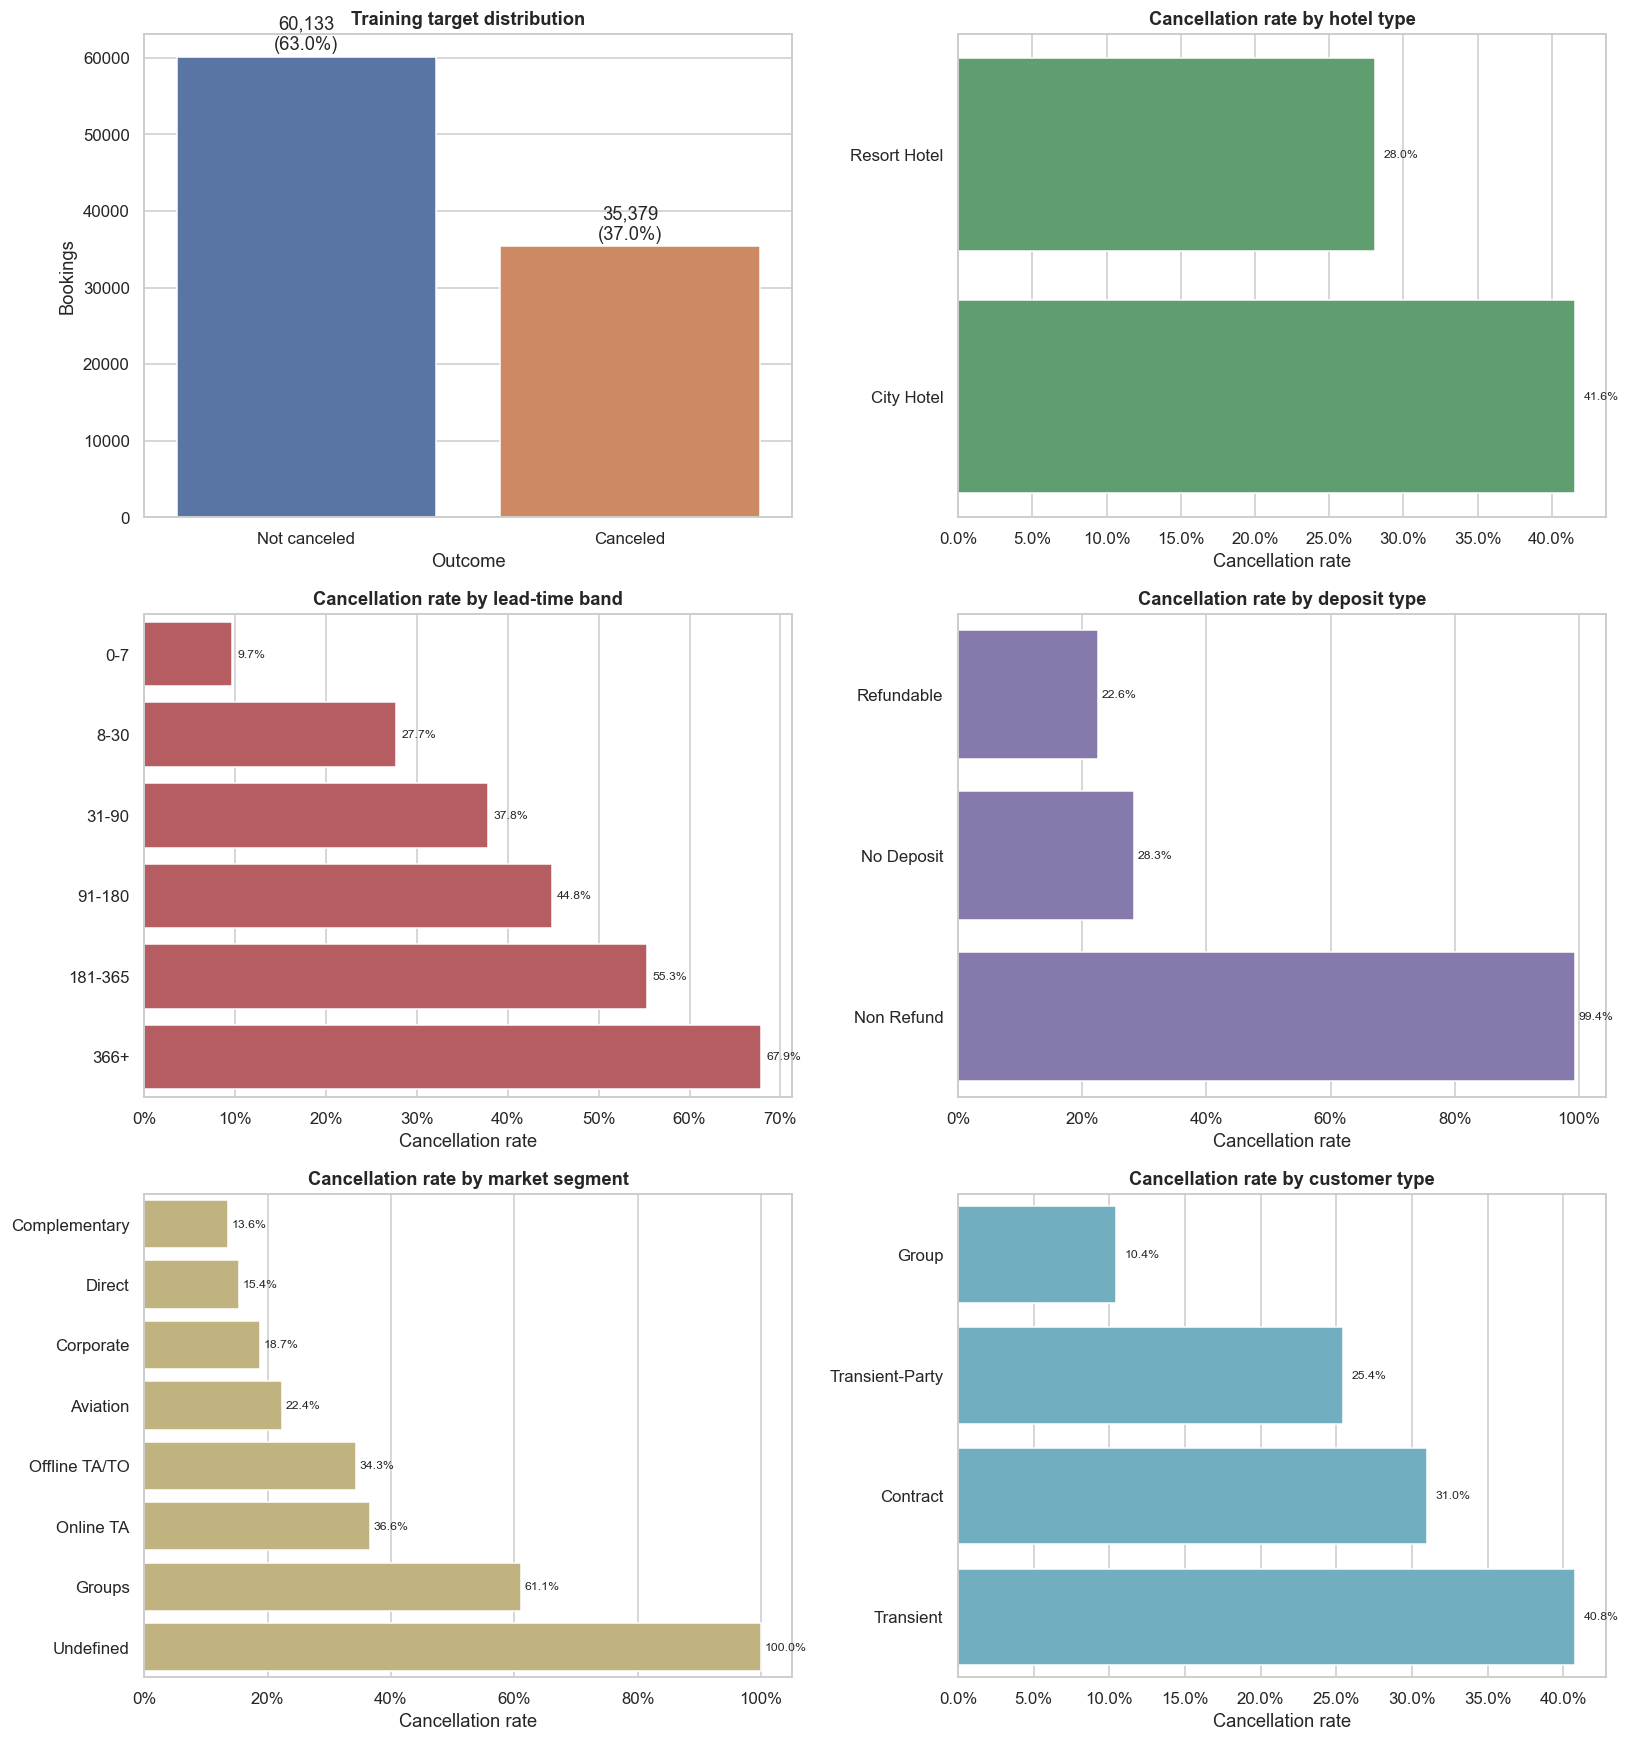

In [9]:
def plot_rate(axis, table, category, title, color="#4c72b0"):
    plot_table = table.copy().sort_values("cancellation_rate", ascending=True)
    sns.barplot(data=plot_table, x="cancellation_rate", y=category, color=color, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("Cancellation rate")
    axis.set_ylabel("")
    axis.xaxis.set_major_formatter(PercentFormatter(1))
    for patch, rate in zip(axis.patches, plot_table["cancellation_rate"]):
        axis.text(rate + 0.006, patch.get_y() + patch.get_height() / 2, f"{rate:.1%}", va="center", fontsize=8)


fig, axes = plt.subplots(3, 2, figsize=(15, 16))
train_target = y_train.value_counts().sort_index()
sns.barplot(
    x=["Not canceled", "Canceled"],
    y=train_target.values,
    hue=["Not canceled", "Canceled"],
    palette=["#4c72b0", "#dd8452"],
    legend=False,
    ax=axes[0, 0],
)
axes[0, 0].set(title="Training target distribution", xlabel="Outcome", ylabel="Bookings")
for index, count in enumerate(train_target.values):
    axes[0, 0].text(index, count + 900, f"{count:,}\n({count / len(y_train):.1%})", ha="center")

plot_rate(axes[0, 1], segment_tables["Hotel type"], "hotel", "Cancellation rate by hotel type", "#55a868")
plot_rate(axes[1, 0], segment_tables["Lead-time band (days)"], "lead_time_band", "Cancellation rate by lead-time band", "#c44e52")
plot_rate(axes[1, 1], segment_tables["Deposit type"], "deposit_type", "Cancellation rate by deposit type", "#8172b3")
plot_rate(axes[2, 0], segment_tables["Market segment"], "market_segment", "Cancellation rate by market segment", "#ccb974")
plot_rate(axes[2, 1], segment_tables["Customer type"], "customer_type", "Cancellation rate by customer type", "#64b5cd")
plt.tight_layout()
plt.show()

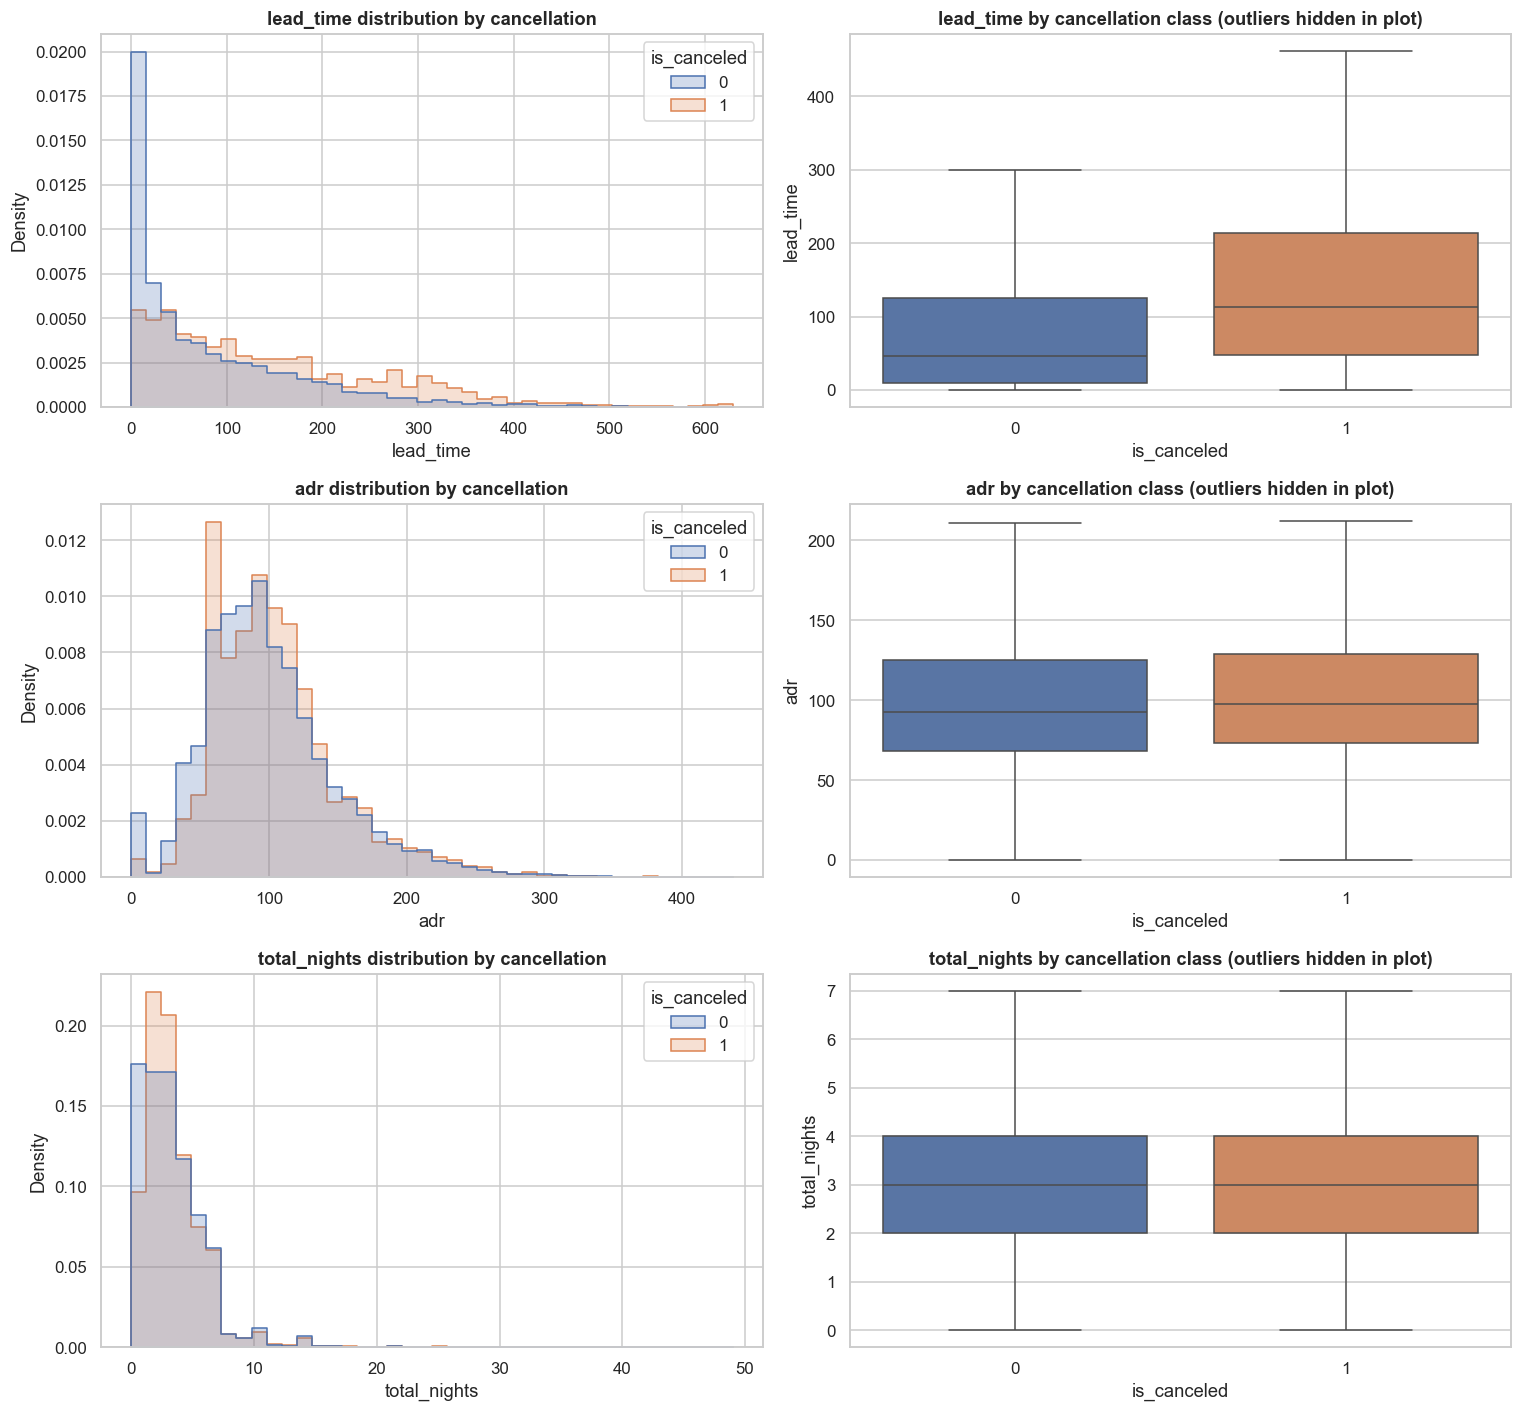

The plots use a reproducible training sample for readability; segment tables use all training rows.


In [10]:
numeric_eda_features = ["lead_time", "adr", "total_nights"]
plot_sample = train_frame.sample(n=min(30_000, len(train_frame)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(len(numeric_eda_features), 2, figsize=(14, 13))

for row, feature in enumerate(numeric_eda_features):
    sns.histplot(
        data=plot_sample,
        x=feature,
        hue=TARGET,
        hue_order=[0, 1],
        stat="density",
        common_norm=False,
        element="step",
        bins=40,
        palette={0: "#4c72b0", 1: "#dd8452"},
        ax=axes[row, 0],
    )
    axes[row, 0].set_title(f"{feature} distribution by cancellation")
    axes[row, 0].set_ylabel("Density")
    sns.boxplot(
        data=plot_sample,
        x=TARGET,
        y=feature,
        hue=TARGET,
        palette={0: "#4c72b0", 1: "#dd8452"},
        legend=False,
        showfliers=False,
        ax=axes[row, 1],
    )
    axes[row, 1].set_title(f"{feature} by cancellation class (outliers hidden in plot)")
    axes[row, 1].set_xlabel("is_canceled")

plt.tight_layout()
plt.show()
print("The plots use a reproducible training sample for readability; segment tables use all training rows.")

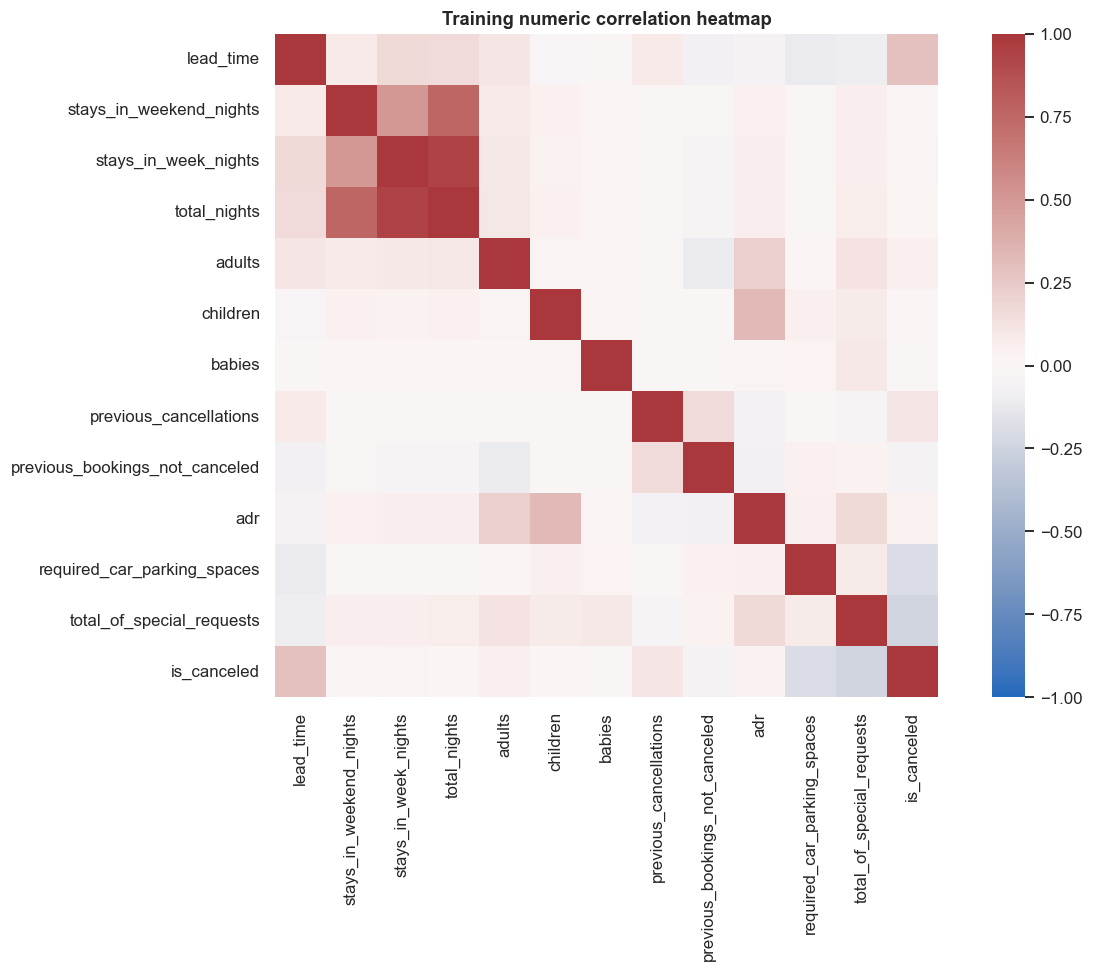

Correlations are descriptive linear associations, not causal effects.


In [11]:
correlation_columns = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    TARGET,
]
correlations = train_frame[correlation_columns].corr(method="pearson")
plt.figure(figsize=(12, 9))
sns.heatmap(correlations, cmap="vlag", center=0, vmin=-1, vmax=1, square=True)
plt.title("Training numeric correlation heatmap")
plt.tight_layout()
plt.show()
print("Correlations are descriptive linear associations, not causal effects.")

## 8. Business-impact proxies on training data

`total_nights = stays_in_weekend_nights + stays_in_week_nights` and `estimated_booking_value = ADR × total_nights`. The canceled value and canceled room-night volume are exposure proxies, not confirmed realized revenue loss. They ignore taxes, ancillary spend, overbooking, resale, no-shows, refunds, commissions, and replacement bookings. The single invalid negative ADR is unavailable for value aggregation but remains represented in counts and room-night volume.

In [12]:
train_frame["estimated_booking_value"] = train_frame["adr"] * train_frame["total_nights"]
train_frame["estimated_canceled_booking_value"] = np.where(
    train_frame[TARGET].eq(1), train_frame["estimated_booking_value"], 0.0
)
train_frame["estimated_canceled_room_nights"] = (
    train_frame[TARGET] * train_frame["total_nights"]
)


def impact_summary(frame, segment):
    result = (
        frame.groupby(segment, dropna=False, observed=True)
        .agg(
            bookings=(TARGET, "size"),
            cancellations=(TARGET, "sum"),
            booked_room_nights=("total_nights", "sum"),
            estimated_booking_value=("estimated_booking_value", "sum"),
            estimated_canceled_booking_value=("estimated_canceled_booking_value", "sum"),
            estimated_canceled_room_nights=("estimated_canceled_room_nights", "sum"),
        )
        .reset_index()
    )
    result["cancellation_rate"] = result["cancellations"] / result["bookings"]
    total_risk = result["estimated_canceled_booking_value"].sum()
    result["share_of_estimated_value_at_risk"] = (
        result["estimated_canceled_booking_value"] / total_risk
    )
    return result.sort_values("estimated_canceled_booking_value", ascending=False)


impact_dimensions = {
    "Hotel type": "hotel",
    "Deposit type": "deposit_type",
    "Market segment": "market_segment",
    "Lead-time band": "lead_time_band",
}
impact_tables = {}
for label, segment in impact_dimensions.items():
    print(f"\nRevenue-at-risk proxy by {label.lower()}")
    table = impact_summary(train_frame, segment)
    impact_tables[label] = table
    display(table)

impact_totals = pd.Series(
    {
        "Booked room nights": train_frame["total_nights"].sum(),
        "Estimated booking value": train_frame["estimated_booking_value"].sum(),
        "Estimated canceled booking value": train_frame["estimated_canceled_booking_value"].sum(),
        "Estimated canceled room nights": train_frame["estimated_canceled_room_nights"].sum(),
        "Bookings with unavailable ADR value": train_frame["estimated_booking_value"].isna().sum(),
    },
    name="training_proxy_total",
)
display(impact_totals.to_frame())


Revenue-at-risk proxy by hotel type


,hotel,bookings,cancellations,booked_room_nights,estimated_booking_value,estimated_canceled_booking_value,estimated_canceled_room_nights,cancellation_rate,share_of_estimated_value_at_risk
0,City Hotel,63585,26424,189139,"20,208,726.250","8,649,750.150",80487,0.416,0.647
1,Resort Hotel,31927,8955,138123,"13,932,554.970","4,729,541.860",43041,0.280,0.353



Revenue-at-risk proxy by deposit type


,deposit_type,bookings,cancellations,booked_room_nights,estimated_booking_value,estimated_canceled_booking_value,estimated_canceled_room_nights,cancellation_rate,share_of_estimated_value_at_risk
0,No Deposit,83662,23705,294790,"31,180,146.120","10,454,604.380",91572,0.283,0.781
1,Non Refund,11717,11644,31964,"2,920,181.720","2,907,210.100",31799,0.994,0.217
2,Refundable,133,30,508,"40,953.380","17,477.530",157,0.226,0.001



Revenue-at-risk proxy by market segment


,market_segment,bookings,cancellations,booked_room_nights,estimated_booking_value,estimated_canceled_booking_value,estimated_canceled_room_nights,cancellation_rate,share_of_estimated_value_at_risk
6,Online TA,45214,16561,161311,"19,118,514.830","8,149,962.900",65965,0.366,0.609
4,Groups,15930,9727,47794,"3,764,476.460","2,264,409.620",27829,0.611,0.169
5,Offline TA/TO,19370,6639,75514,"6,515,385.820","1,998,549.000",21458,0.343,0.149
3,Direct,9977,1534,32163,"4,050,048.730","795,123.890",6060,0.154,0.059
2,Corporate,4224,791,8775,"616,061.500","155,978.610",1954,0.187,0.012
0,Aviation,192,43,705,"72,784.360","15,029.000",148,0.224,0.001
1,Complementary,603,82,997,"3,961.520",190.990,111,0.136,0.000
7,Undefined,2,2,3,48.000,48.000,3,1.000,0.000



Revenue-at-risk proxy by lead-time band


,lead_time_band,bookings,cancellations,booked_room_nights,estimated_booking_value,estimated_canceled_booking_value,estimated_canceled_room_nights,cancellation_rate,share_of_estimated_value_at_risk
3,91-180,21246,9526,86648,"9,547,301.760","4,143,576.590",35866,0.448,0.310
4,181-365,17138,9482,71086,"6,915,539.970","3,497,037.440",35582,0.553,0.261
2,31-90,23647,8941,84486,"9,075,460.430","3,474,382.990",30769,0.378,0.260
1,8-30,15160,4204,46862,"5,091,971.380","1,623,717.970",13807,0.277,0.121
0,0-7,15834,1538,31705,"3,000,688.540","356,855.740",3493,0.097,0.027
5,366+,2487,1688,6475,"510,319.140","283,721.280",4011,0.679,0.021


,training_proxy_total
Booked room nights,"327,262.000"
Estimated booking value,"34,141,281.220"
Estimated canceled booking value,"13,379,292.010"
Estimated canceled room nights,"123,528.000"
Bookings with unavailable ADR value,1.000


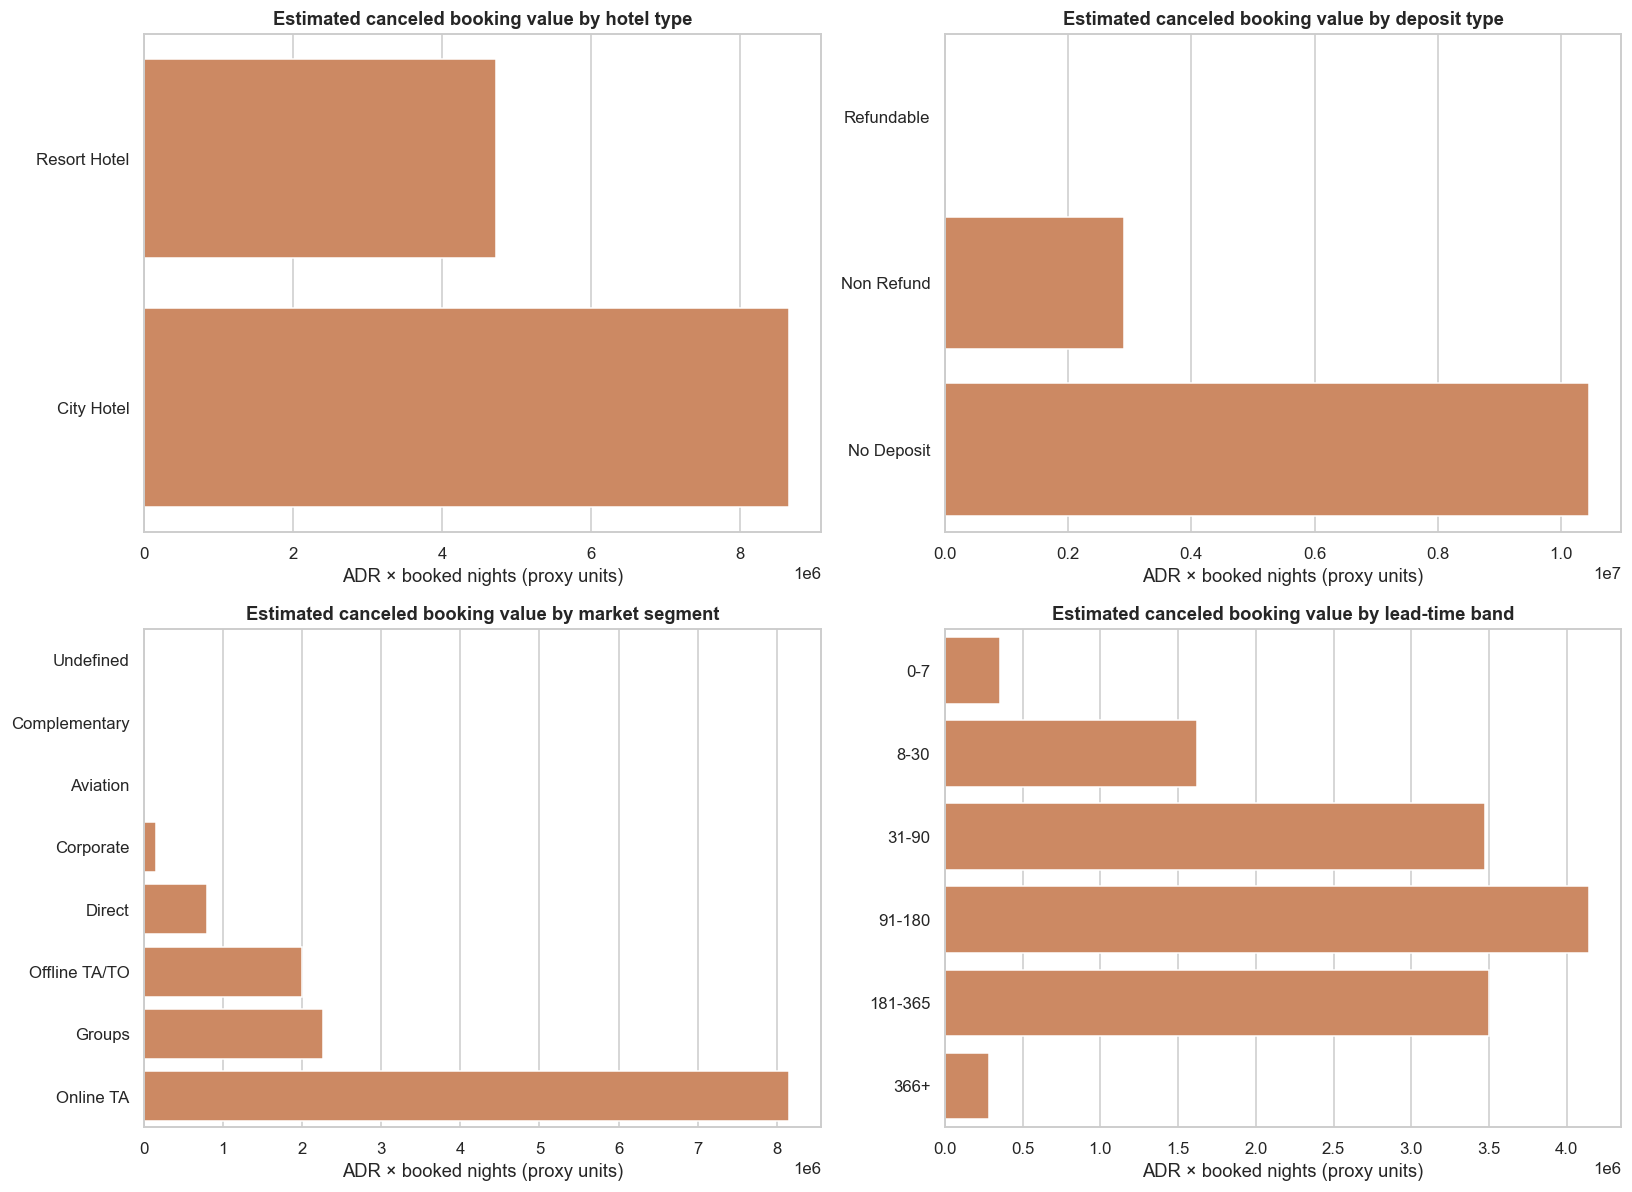

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for (label, segment), axis in zip(impact_dimensions.items(), axes.flat):
    table = impact_tables[label].sort_values("estimated_canceled_booking_value", ascending=True)
    sns.barplot(
        data=table,
        x="estimated_canceled_booking_value",
        y=segment,
        color="#dd8452",
        ax=axis,
    )
    axis.set_title(f"Estimated canceled booking value by {label.lower()}")
    axis.set_xlabel("ADR × booked nights (proxy units)")
    axis.set_ylabel("")
plt.tight_layout()
plt.show()

## 9. Leakage-safe preprocessing and candidate models

Numeric medians and categorical modes are learned inside each fold. Logistic Regression also receives standardized numeric features. Categorical values are one-hot encoded with `handle_unknown='ignore'`; rare categories are grouped by a training-derived minimum-frequency rule. Random Forest and CatBoost use the same imputation and encoding without numeric scaling. The fixed, reproducible candidates are compared with shuffled five-fold stratified cross-validation using positive-class F1 as the primary metric. ROC-AUC breaks effective ties within 0.005 F1.

In [14]:
numeric_for_logistic = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
numeric_for_trees = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=25,
                sparse_output=True,
            ),
        ),
    ]
)

logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_for_logistic, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_for_trees, numeric_features),
        ("categorical", clone(categorical_pipeline), categorical_features),
    ],
    remainder="drop",
)

candidate_models = {
    "Dummy baseline": Pipeline(
        steps=[
            ("preprocessor", clone(tree_preprocessor)),
            ("model", DummyClassifier(strategy="prior", random_state=RANDOM_STATE)),
        ]
    ),
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", clone(logistic_preprocessor)),
            (
                "model",
                LogisticRegression(
                    C=1.0,
                    class_weight="balanced",
                    max_iter=2_000,
                    solver="liblinear",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", clone(tree_preprocessor)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=150,
                    max_depth=16,
                    min_samples_leaf=2,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "CatBoost": Pipeline(
        steps=[
            ("preprocessor", clone(tree_preprocessor)),
            (
                "model",
                CatBoostClassifier(
                    iterations=200,
                    depth=6,
                    learning_rate=0.08,
                    loss_function="Logloss",
                    auto_class_weights="Balanced",
                    verbose=False,
                    random_seed=RANDOM_STATE,
                    thread_count=-1,
                    allow_writing_files=False,
                ),
            ),
        ]
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}
print("Model inputs:", len(feature_columns), "original booking-time columns")
print("Cross-validation: 5 shuffled stratified folds")

Model inputs: 24 original booking-time columns
Cross-validation: 5 shuffled stratified folds


## 10. Cross-validation and model selection

The candidates are evaluated only on the training partition. A difference of at most 0.005 mean CV F1 is treated as an effective tie; ROC-AUC is the tie-breaker among those contenders. Test metrics are not available when this decision is made.

In [15]:
cv_rows = []
for name, pipeline in candidate_models.items():
    print(f"Cross-validating {name}...")
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )
    row = {"Model": name}
    for metric in scoring:
        row[f"Mean CV {metric}"] = scores[f"test_{metric}"].mean()
        row[f"CV {metric} std"] = scores[f"test_{metric}"].std(ddof=1)
    cv_rows.append(row)

cv_comparison = (
    pd.DataFrame(cv_rows)
    .set_index("Model")
    .sort_values(["Mean CV f1", "Mean CV roc_auc"], ascending=False)
)
display(cv_comparison)

best_cv_f1 = cv_comparison["Mean CV f1"].max()
contenders = cv_comparison[
    cv_comparison["Mean CV f1"] >= best_cv_f1 - F1_TIE_TOLERANCE
]
preferred_name = contenders.sort_values(
    ["Mean CV roc_auc", "Mean CV f1"], ascending=False
).index[0]

print(f"Preferred model selected from CV only: {preferred_name}")
print(f"F1 tie tolerance: {F1_TIE_TOLERANCE:.3f}")
print(f"Models within tolerance: {', '.join(contenders.index)}")

Cross-validating Dummy baseline...


Cross-validating Logistic Regression...


Cross-validating Random Forest...


Cross-validating CatBoost...


,Mean CV precision,CV precision std,Mean CV recall,CV recall std,Mean CV f1,CV f1 std,Mean CV roc_auc,CV roc_auc std,Mean CV pr_auc,CV pr_auc std
Model,,,,,,,,,,
Random Forest,0.699,0.004,0.845,0.007,0.765,0.003,0.913,0.002,0.881,0.003
CatBoost,0.694,0.004,0.838,0.003,0.759,0.003,0.908,0.002,0.873,0.002
Logistic Regression,0.693,0.003,0.703,0.003,0.698,0.003,0.860,0.003,0.816,0.004
Dummy baseline,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000,0.370,0.000


Preferred model selected from CV only: Random Forest
F1 tie tolerance: 0.005
Models within tolerance: Random Forest


## 11. Final evaluation on the untouched test set

Each candidate is fitted once on all training rows and evaluated once on the held-out rows at the default threshold of 0.5. Positive-class precision, recall, F1, ROC-AUC, PR-AUC, and confusion matrices are reported. The threshold is not tuned on the test set.

In [16]:
fitted_models = {}
test_predictions = {}
test_probabilities = {}
test_rows = []

for name, pipeline in candidate_models.items():
    print(f"Fitting {name} on the full training partition...")
    fitted = clone(pipeline).fit(X_train, y_train)
    fitted_models[name] = fitted
    predictions = fitted.predict(X_test).astype(int)
    probabilities = fitted.predict_proba(X_test)[:, 1]
    test_predictions[name] = predictions
    test_probabilities[name] = probabilities
    test_rows.append(
        {
            "Model": name,
            "Precision": precision_score(y_test, predictions, zero_division=0),
            "Recall": recall_score(y_test, predictions, zero_division=0),
            "F1": f1_score(y_test, predictions, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, probabilities),
            "PR-AUC": average_precision_score(y_test, probabilities),
        }
    )

test_results = pd.DataFrame(test_rows).set_index("Model")
display(test_results)
selected_test = test_results.loc[preferred_name]
print(
    f"Selected {preferred_name}: F1={selected_test['F1']:.3f}, "
    f"ROC-AUC={selected_test['ROC-AUC']:.3f}, PR-AUC={selected_test['PR-AUC']:.3f}"
)

Fitting Dummy baseline on the full training partition...


Fitting Logistic Regression on the full training partition...


Fitting Random Forest on the full training partition...


Fitting CatBoost on the full training partition...


,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,
Dummy baseline,0.000,0.000,0.000,0.500,0.370
Logistic Regression,0.696,0.703,0.699,0.859,0.814
Random Forest,0.701,0.844,0.766,0.914,0.881
CatBoost,0.696,0.839,0.761,0.908,0.872


Selected Random Forest: F1=0.766, ROC-AUC=0.914, PR-AUC=0.881


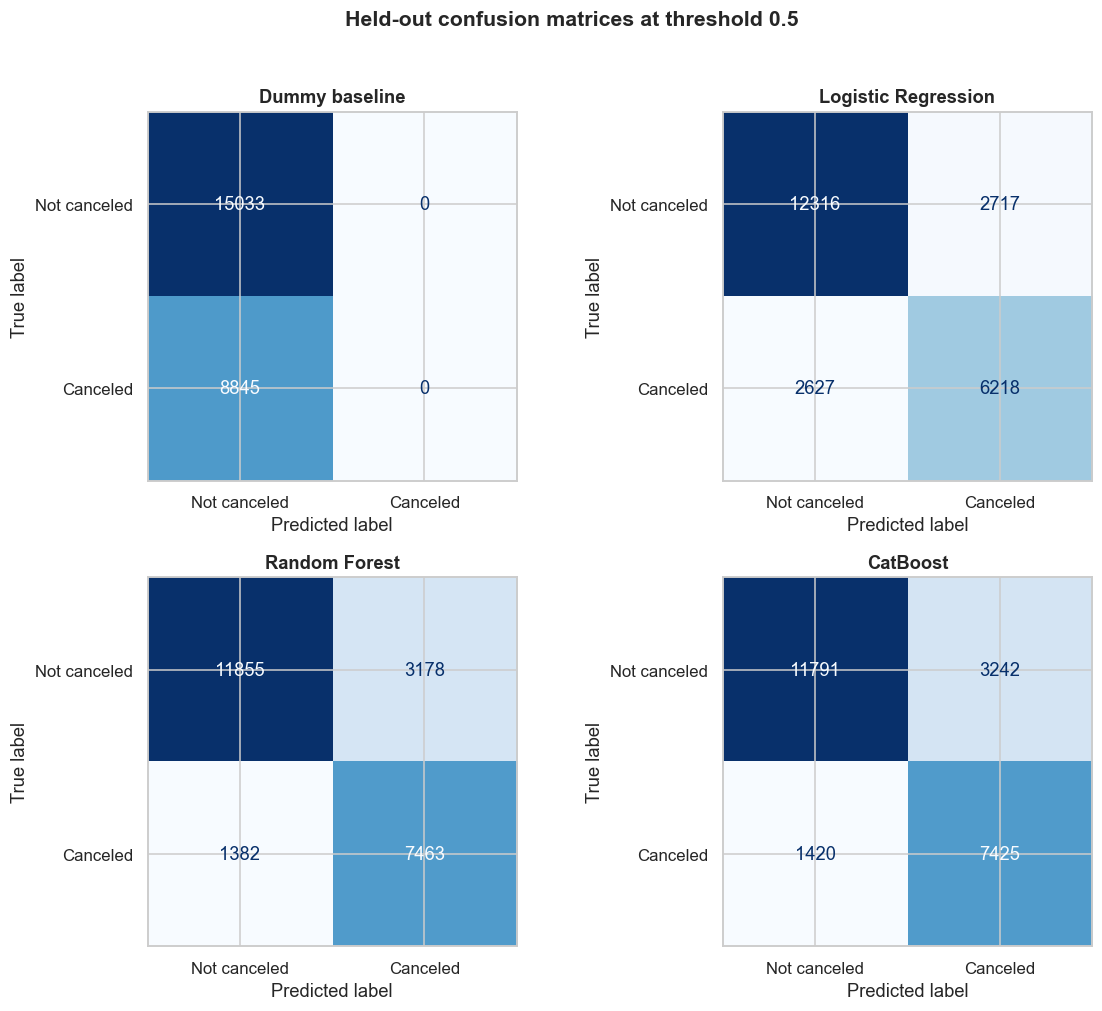

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for (name, predictions), axis in zip(test_predictions.items(), axes.flat):
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, predictions),
        display_labels=["Not canceled", "Canceled"],
    ).plot(ax=axis, colorbar=False, cmap="Blues")
    axis.set_title(name)
plt.suptitle("Held-out confusion matrices at threshold 0.5", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

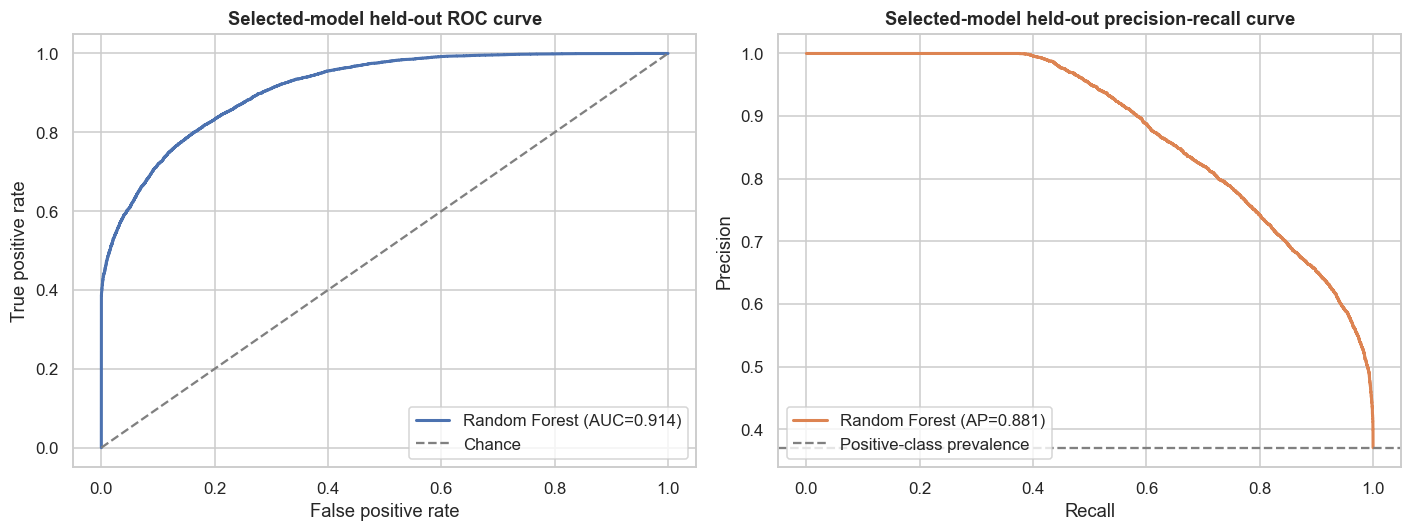

Selected-model confusion matrix [[TN, FP], [FN, TP]]:
[[11855  3178]
 [ 1382  7463]]


In [18]:
selected_probabilities = test_probabilities[preferred_name]
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, selected_probabilities)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, selected_probabilities)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f"{preferred_name} (AUC={selected_test['ROC-AUC']:.3f})",
)
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Chance")
axes[0].set(title="Selected-model held-out ROC curve", xlabel="False positive rate", ylabel="True positive rate")
axes[0].legend(loc="lower right")

axes[1].plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    color="#dd8452",
    label=f"{preferred_name} (AP={selected_test['PR-AUC']:.3f})",
)
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Positive-class prevalence")
axes[1].set(title="Selected-model held-out precision-recall curve", xlabel="Recall", ylabel="Precision")
axes[1].legend(loc="lower left")
plt.tight_layout()
plt.show()

selected_confusion = confusion_matrix(y_test, test_predictions[preferred_name])
print("Selected-model confusion matrix [[TN, FP], [FN, TP]]:")
print(selected_confusion)

## 12. Interpretation at original feature level

Permutation importance measures the decrease in held-out F1 when one original booking-time column is shuffled through the complete selected pipeline. The test set is used only for this final interpretive audit; the result does not trigger feature selection or model changes. Importance is predictive association, not causality.

,Feature,Mean F1 decrease,Std. F1 decrease
0,country,0.105,0.001
1,market_segment,0.060,0.002
2,lead_time,0.056,0.002
3,deposit_type,0.045,0.001
4,customer_type,0.041,0.002
5,adr,0.026,0.002
6,arrival_date_year,0.023,0.002
7,distribution_channel,0.016,0.001
8,previous_cancellations,0.012,0.001
9,hotel,0.011,0.001


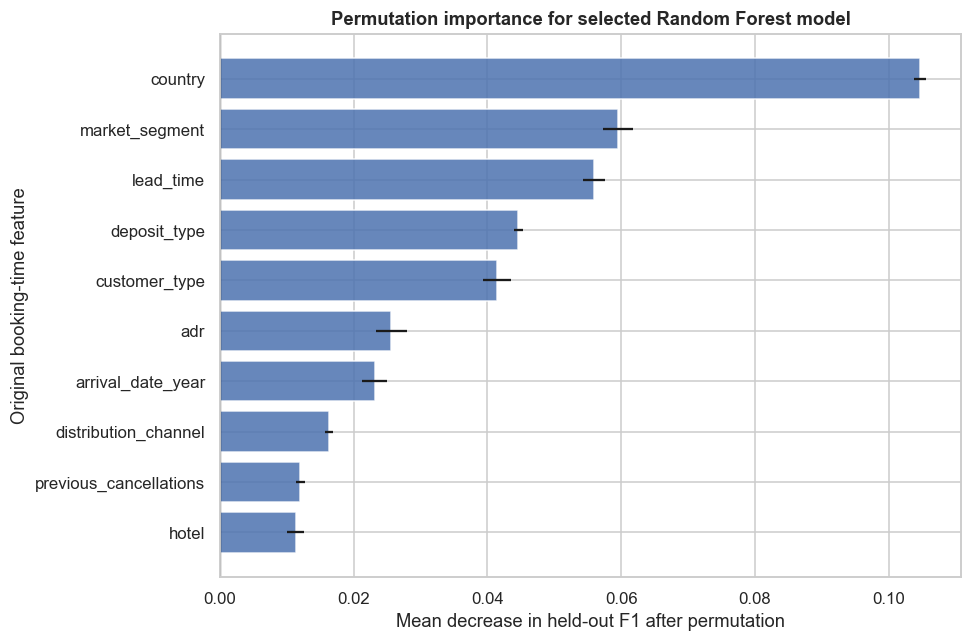

In [19]:
selected_model = fitted_models[preferred_name]
permutation = permutation_importance(
    selected_model,
    X_test,
    y_test,
    scoring=make_scorer(f1_score, zero_division=0),
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
importance_table = (
    pd.DataFrame(
        {
            "Feature": X_test.columns,
            "Mean F1 decrease": permutation.importances_mean,
            "Std. F1 decrease": permutation.importances_std,
        }
    )
    .sort_values("Mean F1 decrease", ascending=False)
    .reset_index(drop=True)
)
display(importance_table.head(10))

plot_data = importance_table.head(10).sort_values("Mean F1 decrease")
plt.figure(figsize=(9, 6))
plt.barh(
    plot_data["Feature"],
    plot_data["Mean F1 decrease"],
    xerr=plot_data["Std. F1 decrease"],
    color="#4c72b0",
    alpha=0.85,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Mean decrease in held-out F1 after permutation")
plt.ylabel("Original booking-time feature")
plt.title(f"Permutation importance for selected {preferred_name} model")
plt.tight_layout()
plt.show()

In [20]:
top_profile_features = importance_table.head(8)["Feature"].tolist()
profile_tables = []

for feature in top_profile_features:
    values = train_frame[feature]
    if feature in numeric_features and values.nunique(dropna=True) > 8:
        level = pd.qcut(values, q=4, duplicates="drop")
    else:
        level = values.astype("string").fillna("Missing")
    profile = (
        train_frame.assign(level=level)
        .groupby("level", observed=True, dropna=False)[TARGET]
        .agg(bookings="size", cancellations="sum", cancellation_rate="mean")
        .reset_index()
    )
    profile.insert(0, "feature", feature)
    profile["level"] = profile["level"].astype(str)
    profile_tables.append(profile)

direction_profiles = pd.concat(profile_tables, ignore_index=True)
display(direction_profiles)
print("Practical training-only profiles for the most influential variables:")
for feature in top_profile_features:
    reliable = direction_profiles.query("feature == @feature and bookings >= 100").sort_values("cancellation_rate")
    if reliable.empty:
        continue
    low = reliable.iloc[0]
    high = reliable.iloc[-1]
    print(
        f"- {feature}: observed cancellation ranges from {low['cancellation_rate']:.1%} "
        f"({low['level']}, n={int(low['bookings']):,}) to {high['cancellation_rate']:.1%} "
        f"({high['level']}, n={int(high['bookings']):,})."
    )
print("These directions describe predictive associations and may reflect confounding.")

,feature,level,bookings,cancellations,cancellation_rate
0,country,ABW,2,0,0.000
1,country,AGO,291,165,0.567
2,country,AIA,1,0,0.000
3,country,ALB,9,2,0.222
4,country,AND,5,4,0.800
...,...,...,...,...,...
200,distribution_channel,Corporate,5315,1184,0.223
201,distribution_channel,Direct,11610,2033,0.175
202,distribution_channel,GDS,156,28,0.179
203,distribution_channel,TA/TO,78427,32130,0.410


Practical training-only profiles for the most influential variables:
- country: observed cancellation ranges from 14.7% (JPN, n=163) to 56.7% (AGO, n=291).
- market_segment: observed cancellation ranges from 13.6% (Complementary, n=603) to 61.1% (Groups, n=15,930).
- lead_time: observed cancellation ranges from 14.7% ((-0.001, 18.0], n=24,218) to 55.4% ((160.0, 737.0], n=23,790).
- deposit_type: observed cancellation ranges from 22.6% (Refundable, n=133) to 99.4% (Non Refund, n=11,717).
- customer_type: observed cancellation ranges from 10.4% (Group, n=442) to 40.8% (Transient, n=71,610).
- adr: observed cancellation ranges from 33.7% ((-0.001, 69.29], n=23,889) to 39.0% ((94.5, 126.0], n=24,430).
- arrival_date_year: observed cancellation ranges from 35.8% (2016, n=45,448) to 38.8% (2017, n=32,505).
- distribution_channel: observed cancellation ranges from 17.5% (Direct, n=11,610) to 41.0% (TA/TO, n=78,427).
These directions describe predictive associations and may reflect confounding

## 13. Business recommendations

The recommendations below use observed training segments and selected-model outputs. They prioritize operational review and controlled testing rather than claiming causal effects.

In [21]:
def highest_reliable_rate(table, category, minimum_bookings=500):
    reliable = table[table["bookings"] >= minimum_bookings]
    return reliable.sort_values("cancellation_rate", ascending=False).iloc[0]


deposit_high = highest_reliable_rate(segment_tables["Deposit type"], "deposit_type")
lead_high = highest_reliable_rate(segment_tables["Lead-time band (days)"], "lead_time_band")
market_high = highest_reliable_rate(segment_tables["Market segment"], "market_segment")
hotel_risk = impact_tables["Hotel type"].iloc[0]

recommendations = [
    (
        f"Review deposit and cancellation policies for the {deposit_high['deposit_type']} segment, "
        f"which had a {deposit_high['cancellation_rate']:.1%} training cancellation rate across "
        f"{int(deposit_high['bookings']):,} bookings. Test policy changes before rollout."
    ),
    (
        f"Prioritize confirmation reminders or reconfirmation workflows for the {lead_high['lead_time_band']} "
        f"day lead-time band and the {market_high['market_segment']} market segment, while monitoring false positives."
    ),
    (
        f"Use predicted cancellation probabilities to plan inventory and staffing for {hotel_risk['hotel']}, "
        "the hotel type with the larger ADR-based canceled-booking-value proxy in the training partition."
    ),
    (
        "Track cancellation rates, predicted-risk distributions, room-night exposure, and precision/recall over time. "
        "Revalidate chronologically before operational deployment."
    ),
    (
        "Run controlled experiments before changing pricing, deposits, reminders, or channel strategy. "
        "The model ranks risk; it does not estimate intervention effects."
    ),
]
for number, recommendation in enumerate(recommendations, start=1):
    print(f"{number}. {recommendation}")

1. Review deposit and cancellation policies for the Non Refund segment, which had a 99.4% training cancellation rate across 11,717 bookings. Test policy changes before rollout.
2. Prioritize confirmation reminders or reconfirmation workflows for the 366+ day lead-time band and the Groups market segment, while monitoring false positives.
3. Use predicted cancellation probabilities to plan inventory and staffing for City Hotel, the hotel type with the larger ADR-based canceled-booking-value proxy in the training partition.
4. Track cancellation rates, predicted-risk distributions, room-night exposure, and precision/recall over time. Revalidate chronologically before operational deployment.
5. Run controlled experiments before changing pricing, deposits, reminders, or channel strategy. The model ranks risk; it does not estimate intervention effects.


## 14. Example booking score

One held-out booking is represented by named columns and passed through the complete fitted pipeline. The class uses the default 0.5 threshold. The probability is a risk estimate, not a certainty.

In [22]:
example_booking = X_test.iloc[[0]].copy()
example_probability = float(selected_model.predict_proba(example_booking)[:, 1][0])
example_prediction = int(selected_model.predict(example_booking)[0])

display(example_booking.T.rename(columns={example_booking.index[0]: "value"}))
print(f"Selected model: {preferred_name}")
print(
    f"Predicted class at threshold 0.5: {example_prediction} "
    f"({'Canceled' if example_prediction else 'Not canceled'})"
)
print(f"Predicted cancellation probability: {example_probability:.3%}")
print("Interpretation: this is an estimated risk based on historical associations, not a certainty.")

,value
lead_time,14
arrival_date_year,2016
arrival_date_week_number,30
arrival_date_day_of_month,21
stays_in_weekend_nights,0
stays_in_week_nights,2
adults,2.000
children,0.000
babies,0.000
is_repeated_guest,0


Selected model: Random Forest
Predicted class at threshold 0.5: 0 (Not canceled)
Predicted cancellation probability: 30.913%
Interpretation: this is an estimated risk based on historical associations, not a certainty.


## 15. Conclusions generated from this run

The final cell prints the exact values used to update the README, preventing findings from being invented before notebook execution.

In [23]:
def highest_and_lowest(table, category, minimum_bookings=500):
    reliable = table[table["bookings"] >= minimum_bookings].sort_values("cancellation_rate")
    low = reliable.iloc[0]
    high = reliable.iloc[-1]
    return {
        "lowest": {
            "level": str(low[category]),
            "bookings": int(low["bookings"]),
            "rate": round(float(low["cancellation_rate"]), 6),
        },
        "highest": {
            "level": str(high[category]),
            "bookings": int(high["bookings"]),
            "rate": round(float(high["cancellation_rate"]), 6),
        },
    }


summary = {
    "dataset_rows": int(raw_data.shape[0]),
    "dataset_columns": int(raw_data.shape[1]),
    "file_sha256": file_hash,
    "arrival_date_min": str(arrival_dates.min().date()),
    "arrival_date_max": str(arrival_dates.max().date()),
    "raw_cancellation_rate": round(float(raw_data[TARGET].mean()), 6),
    "training_cancellation_rate": round(float(y_train.mean()), 6),
    "selected_model": preferred_name,
    "selected_test": {metric: round(float(value), 6) for metric, value in selected_test.items()},
    "selected_confusion_matrix": selected_confusion.tolist(),
    "top_permutation_features": importance_table.head(10)["Feature"].tolist(),
    "cv_results": {
        name: {
            "mean_f1": round(float(row["Mean CV f1"]), 6),
            "mean_roc_auc": round(float(row["Mean CV roc_auc"]), 6),
            "mean_pr_auc": round(float(row["Mean CV pr_auc"]), 6),
        }
        for name, row in cv_comparison.iterrows()
    },
    "test_results": {
        name: {metric: round(float(value), 6) for metric, value in row.items()}
        for name, row in test_results.iterrows()
    },
    "segment_highlights": {
        "hotel": highest_and_lowest(segment_tables["Hotel type"], "hotel"),
        "lead_time_band": highest_and_lowest(segment_tables["Lead-time band (days)"], "lead_time_band"),
        "deposit_type": highest_and_lowest(segment_tables["Deposit type"], "deposit_type"),
        "market_segment": highest_and_lowest(segment_tables["Market segment"], "market_segment"),
        "customer_type": highest_and_lowest(segment_tables["Customer type"], "customer_type"),
    },
    "training_business_impact": {
        "booked_room_nights": int(train_frame["total_nights"].sum()),
        "estimated_booking_value": round(float(train_frame["estimated_booking_value"].sum()), 2),
        "estimated_canceled_booking_value": round(float(train_frame["estimated_canceled_booking_value"].sum()), 2),
        "estimated_canceled_room_nights": int(train_frame["estimated_canceled_room_nights"].sum()),
    },
}

print(f"Selected model: {preferred_name}")
print(f"Held-out positive-class F1: {selected_test['F1']:.3f}")
print(f"Held-out ROC-AUC: {selected_test['ROC-AUC']:.3f}")
print(f"Held-out PR-AUC: {selected_test['PR-AUC']:.3f}")
print(f"Training cancellation prevalence: {y_train.mean():.1%}")
print("Top permutation features:", ", ".join(summary["top_permutation_features"][:8]))
print("README_SUMMARY_JSON=" + json.dumps(summary, sort_keys=True))

Selected model: Random Forest
Held-out positive-class F1: 0.766
Held-out ROC-AUC: 0.914
Held-out PR-AUC: 0.881
Training cancellation prevalence: 37.0%
Top permutation features: country, market_segment, lead_time, deposit_type, customer_type, adr, arrival_date_year, distribution_channel
README_SUMMARY_JSON={"arrival_date_max": "2017-08-31", "arrival_date_min": "2015-07-01", "cv_results": {"CatBoost": {"mean_f1": 0.759087, "mean_pr_auc": 0.872545, "mean_roc_auc": 0.907704}, "Dummy baseline": {"mean_f1": 0.0, "mean_pr_auc": 0.370414, "mean_roc_auc": 0.5}, "Logistic Regression": {"mean_f1": 0.69795, "mean_pr_auc": 0.81582, "mean_roc_auc": 0.859659}, "Random Forest": {"mean_f1": 0.765138, "mean_pr_auc": 0.880738, "mean_roc_auc": 0.912797}}, "dataset_columns": 32, "dataset_rows": 119390, "file_sha256": "7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06", "raw_cancellation_rate": 0.370416, "segment_highlights": {"customer_type": {"highest": {"bookings": 71610, "level": "Transie

### Limitations and next steps

- The requested random row split does not demonstrate future-period performance. Bookings span 2015-2017, so a chronological holdout is the next validation step.
- The source has no reservation identifier. Duplicate-looking rows may be legitimate separate bookings, but identical profiles can cross random partitions and make validation optimistic.
- Field timestamps are incomplete. The conservative exclusions reduce leakage risk, but a production feature-availability audit against the property-management system is still required.
- ADR × booked nights is an exposure proxy, not realized revenue. It omits taxes, ancillary spend, refunds, commissions, resales, overbooking, and replacement demand.
- Country, channel, customer, hotel, and policy mix may differ from a deployment population and can drift over time.
- Permutation importance and observed segment rates are predictive associations, not causal effects or treatment-effect estimates.
- The 0.5 threshold is not cost optimized. Future threshold selection should use training-only out-of-fold probabilities and explicit operational costs.
- Probability calibration, subgroup review, drift monitoring, data-quality controls, and scheduled performance monitoring are required before production use.

All plots and tables are embedded in this executed notebook. Fitted models remain in kernel memory; the workflow creates no model, plot, report, dashboard, or processed-data files.